# Security assets from VHDL, with an audit trail

**NEORV32: the 41 modules that have a manual reference in the LAsset dataset**

This notebook runs the final version of my pipeline, from raw VHDL to a list of security assets. Then it traces every
listed asset back to the code.

LAsset (arXiv 2601.02624, DATE 2026) asks an LLM to name the security assets of an RTL module and scores the list
against a manual reference. Its list gives a prose justification for each asset, but no RTL line or relationship that the justification rests
on, so the reason cannot be checked against the code. My addition is an evidence layer that is built by code, in front
of the LLM and behind it:

| step | what it is | built by |
|---|---|---|
| 1 occurrence profiles | every place a port or signal name appears gets a number (its **occurrence ID**), its line, and the VHDL structure around it | code (tree-sitter) |
| 2 relationship map | typed records between elements, such as `ctrl.lock GATES ctrl.enable`, each anchored to the occurrence IDs where it holds | code |
| 3 checks | self-tests against hand-read lines, byte-identical rebuilds, line integrity, accuracy against a gold sample | code |
| 4 generation | the final prompt asks the model to cite, for every asset, the occurrence ID and the record its decision rests on | gpt-5.4 (and, as a check, a Claude agent) |
| 5 audit trail | listed asset → occurrence ID → source line → relationship record → is the citation true? | code |

Then the notebook compares the final prompt with LAsset on all 41 modules, and uses the audit trail on two questions
that accuracy numbers cannot answer: **why do the false positives not go down**, and **what else do the occurrence
profiles and the relationship map tell us about each module?**

**How to read it.** Every number is printed by a code cell in this notebook. The prose holds no figures of its own.
Text marked *Reading* is my interpretation, not a measurement.

**Two executors.** The final prompt was run by two models: gpt-5.4 (OpenAI), the final configuration, with three
runs on every one of the 41 modules; and a Claude agent, the executor of the prompt-optimization loop, with three runs
on the tuning modules and one on the held-out modules. The results and the analysis use gpt-5.4; the Claude runs are
shown beside it as a check.

**How to run it.** `pip install -r requirements.txt`, then run all cells. With `RUN_API = False` nothing calls an API
and the notebook runs in a few minutes. With a key in `API.env` and `RUN_API = True`, the generation cell would run
the gpt-5.4 held-out generation; its runs are already on disk, so it skips them.

In [1]:
RUN_API = False   # True: gpt-5.4 held-out generation (26 modules x 3 runs; modules on disk are skipped). Nothing else calls an API.

import sys, json
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "final")
import final_pipeline as FP

ns = FP.setup()          # moves to the repo root, loads the pipeline modules, checks the tree-sitter VHDL grammar
mods = FP.modules(ns.ea)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.width", 220)
pd.set_option("display.max_rows", 120)
print(f"tuning set:   {len(mods['tuning']):>2} modules, {mods['entries']['tuning']} reference entries")
print(f"held-out set: {len(mods['heldout']):>2} modules, {mods['entries']['heldout']} reference entries")

tuning set:   15 modules, 111 reference entries
held-out set: 26 modules, 189 reference entries


## 1. The 41 modules

The manual reference (`data/ground_truth/manual_gt_neorv32.json`, from the LAsset dataset) lists the security assets of 41
NEORV32 modules. One reference entry is one asset of one module.

- **Tuning set, 15 modules.** Every prompt change in the logs was scored here.
- **Held-out set, 26 modules.** The prompt-optimization loop that produced the final prompt never saw these modules.
  Earlier versions were checked on them, so they are held out from the final prompt's tuning, not unseen by me.

The 41 RTL files are LAsset's NEORV32 sources (see `THIRD_PARTY_NOTICES.md`). The tuning modules are in
`data/RTL_data/` (with two control modules, `boot_rom` and `fifo`, and the shared package, none of which has
reference entries) and the held-out modules in
`data/RTL_heldout/`. The table below is also saved as `data/LASSET_41_MODULES.csv`; `sha12` is the start of the
file's SHA-256, so a reader can check that the files are the ones scored here.

In [2]:
import results41 as R41
manifest = R41.manifest(mods)
print(manifest.groupby("split")["entries"].agg(["count", "sum"]).rename(columns={"count": "modules", "sum": "reference entries"}))
manifest.assign(module=manifest["module"].str.replace("neorv32_", "")).set_index(["split", "module"])

         modules  reference entries
split                              
heldout       26                189
tuning        15                111


rtl_path  entries         sha12  lines                                                                                             entities
split   module                                                                                                                                                                                            
tuning  bus                               data/RTL_data/neorv32_bus.vhd       11  b965fa1dfe8d    967  neorv32_bus_switch;neorv32_bus_reg;neorv32_bus_gateway;neorv32_bus_io_switch;neorv32_bus_amo_rmw...
        cache                           data/RTL_data/neorv32_cache.vhd        6  4b1f186c23ae    433                                                                   neorv32_cache;neorv32_cache_memory
        cpu                               data/RTL_data/neorv32_cpu.vhd       14  709a5890b65e    459                                                                                          neorv32_cpu
        cpu_cp_cfu                 data/RTL_data/neorv32_cpu_cp_cfu.vhd       11  5efda1ad0d19    268                                                                                   neorv32_cpu_cp_cfu
        cpu_cp_muldiv           data/RTL_data/neorv32_cpu_cp_muldiv.vhd       12  faebd8e66ead    335                                                                                neorv32_cpu_cp_muldiv
        cpu_pmp                       data/RTL_data/neorv32_cpu_pmp.vhd        6  4402aaa48f08    368                                                                                      neorv32_cpu_pmp
        debug_dtm                   data/RTL_data/neorv32_debug_dtm.vhd        5  7371a84305b0    288                                                                                    neorv32_debug_dtm
        hwspinlock                 data/RTL_data/neorv32_hwspinlock.vhd        2  059bb929d7e7     76                                                                                   neorv32_hwspinlock
        imem                             data/RTL_data/neorv32_imem.vhd        3  5bd92d4c2c3f    189                                                                                         neorv32_imem
        spi                               data/RTL_data/neorv32_spi.vhd        8  0137d0908dc1    386                                                                                          neorv32_spi
        sys                               data/RTL_data/neorv32_sys.vhd        2  52a4fdfb0c32    150                                                                  neorv32_sys_reset;neorv32_sys_clock
        trng                             data/RTL_data/neorv32_trng.vhd        7  85d6ab38ce5d    477                                                                    neorv32_trng;neoTRNG;neoTRNG_cell
        twi                               data/RTL_data/neorv32_twi.vhd        6  3e846e3a04bb    412                                                                                          neorv32_twi
        uart                             data/RTL_data/neorv32_uart.vhd       10  01219a3d48ab    521                                                                                         neorv32_uart
        wdt                               data/RTL_data/neorv32_wdt.vhd        8  b63f4c72f6e1    182                                                                                          neorv32_wdt
heldout cpu_alu                    data/RTL_heldout/neorv32_cpu_alu.vhd       11  ffea607766f5    418                                                                                      neorv32_cpu_alu
        cpu_control            data/RTL_heldout/neorv32_cpu_control.vhd       11  f05fb4f711f5   1746                                                                                  neorv32_cpu_control
        cpu_counters          data/RTL_heldout/neorv32_cpu_counters.vhd       11  f70f5844ffef    355                                                        neorv32_cpu_counters;neorv32_cpu_counters_cnt
   

## 2. Occurrence profiles

An **element** is a port or a signal; a record field such as `ctrl.lock` is an element of its own. An **occurrence** is
one place the element's name appears in the module. Each occurrence gets:

- an **occurrence ID** (1, 2, 3, ... in source order, per element). The generator cites these IDs.
- its **line** and the line's text.
- its **Context**: the enclosing VHDL constructs, innermost first (process, if, case, ...), from the tree-sitter parse.
- its **SITE tags**: the role of the name on that line, for example the target of an assignment (`LHS_PROC`), an
  operand on the right-hand side (`RHS_OPERAND`), or a condition (`IF_COND`).

The cell below rebuilds everything from the VHDL in `data/RTL_data/` and `data/RTL_heldout/`: closed sets (the fixed list of
elements per module, found by regex), occurrence profiles, relationship maps and the generator's inputs. It writes
them under `final/`.

In [3]:
built = FP.build_all(ns, mods)
print(f"built in {built['seconds']} s")
pd.DataFrame(FP.profile_stats(built, mods)).T

built in 42.3 s


,modules,elements,occurrences,relationship records
tuning,15,1641,5760,2834
heldout,26,1713,11997,5934


**Example: `ctrl.lock` in the watchdog timer (`neorv32_wdt`).** Software sets the lock bit; after that the
watchdog's configuration cannot be changed until a reset. Its occurrence profile:

In [4]:
ex = FP.example_element(built, "neorv32_wdt", "neorv32_wdt", "ctrl.lock")
pd.DataFrame(ex["profile"])

,Occurrence ID,Occurrence Lines,Line Text,Context,SITE Tagged
0,1,54,signal ctrl : ctrl_t;,declarative part 35-65 in architecture 32-182,[DECL_FIELD]
1,2,76,ctrl.lock <= '0';,then branch 73-80 in if 73-116 in process bus_access 71-117 in architecture 32-182,[LHS_PROC]
2,3,93,if (ctrl.lock = '0') then,then branch 93-97 in if 93-100 in then branch 92-100 in if 92-107 in then branch 91-107 in if 91...,[IF_COND]
3,4,95,ctrl.lock <= bus_req_i.data(ctrl_lock_c) and ctrl.enable;,then branch 93-97 in if 93-100 in then branch 92-100 in if 92-107 in then branch 91-107 in if 91...,[LHS_PROC]
4,5,110,bus_rsp_o.data(ctrl_lock_c) <= ctrl.lock;,else branch 108-113 in if 91-114 in then branch 90-114 in if 90-115 in elsif branch 81-115 in if...,[DIRR_ASS]


## 3. Relationship map

Each record links an element to another element at the occurrence where the link holds. The types come in pairs:
the element that acts (left) and the element acted on (right).

| type (acts) | type (acted on) | meaning |
|---|---|---|
| CARRIES | COPIES | the value is copied unchanged (the whole right-hand side) |
| SOURCES | DERIVES_FROM | the value is an operand of a computation, a slice or an argument |
| GATES | GATED_BY | an `if` or `when` condition decides whether the other element is assigned, or the element is an operand of `and`/`or` in the value assigned (as on line 95 of the watchdog) |
| SELECTS | SELECTED_BY | a `case` selector or a run-time index decides which value is assigned |
| CONSTRAINS | CONSTRAINED_BY | a comparison with the other element |
| SEQUENCES | CLOCKED_BY | the clock edge that times the update |
| RESETS | RESET_BY | the reset that forces the reset value |

The generator can also cite `CONNECTS`, which is not a record type of the map: it names the element's wiring to a port
of a sub-unit instance. `storage` says whether the element holds its value across clock cycles (`edge`) or is
combinational (`comb`).
The records for `ctrl.lock`:

In [5]:
print("storage:", ex["storage"])
pd.DataFrame([{"type": r["type"], "targets": ", ".join(r["targets"]), "at occurrence": r["at"], "condition": r.get("guard", "")}
              for r in ex["records"]])

storage: edge


,type,targets,at occurrence,condition
0,GATES,"ctrl.enable, ctrl.lock, ctrl.strict, ctrl.timeout",[3],ctrl.lock = '0'
1,GATES,reset_force,[3],not (ctrl.lock = '0')
2,CARRIES,bus_rsp_o.data,[5],
3,CLOCKED_BY,clk_i,[4],
4,RESET_BY,rstn_sys_i,[2],
5,GATED_BY,bus_req_i.addr,[4],bus_req_i.addr(2) = '0'
6,GATED_BY,"bus_req_i.data, ctrl.enable",[4],bus_req_i.data(ctrl_lock_c) and ctrl.enable
7,GATED_BY,bus_req_i.rw,[4],bus_req_i.rw = '1'
8,GATED_BY,bus_req_i.stb,[4],bus_req_i.stb = '1'
9,GATED_BY,ctrl.lock,[4],ctrl.lock = '0'


Across all 41 modules, by type:

In [6]:
types = Counter()
for split in ("tuning", "heldout"):
    for m in mods[split]:
        d = json.loads((built["maps"][split] / f"{m}.json").read_text(encoding="utf-8"))
        types.update(r["type"] for a in ("ports", "signals") for e in d[a] for r in e["relationship"])
pd.Series(types).sort_values(ascending=False).to_frame("records")

,records
GATED_BY,1984
GATES,1604
SOURCES,931
SELECTED_BY,766
DERIVES_FROM,717
CLOCKED_BY,566
RESET_BY,520
COPIES,499
CARRIES,499
SELECTS,257


**What the generator reads.** For each module the generator gets one text: the numbered RTL, then the map with the
occurrence IDs and the line of each record. This is the part of `neorv32_wdt`'s input that describes `ctrl.lock`:

In [7]:
text = (built["traced_inputs"] / "tuning" / "neorv32_wdt.txt").read_text(encoding="utf-8").splitlines()
start = next(i for i, l in enumerate(text) if l.startswith("SIGNAL ") and '"name":"ctrl.lock"' in l)
end = next(i for i in range(start + 1, len(text)) if text[i].startswith(("SIGNAL ", "PORT ")))
print("\n".join(text[start:end]))

SIGNAL {"name":"ctrl.lock","entity":"neorv32_wdt","kind":"register","handling":["ORIGINATES","CONSUMES"],"storage":"edge"}
    {"occurrences":[{"id":1,"line":54},{"id":2,"line":76},{"id":3,"line":93},{"id":4,"line":95},{"id":5,"line":110}]}
    {"constant_drivers":[{"at":2,"value":"'0'","lines":[76]}]}
    {"type":"GATES","at":[3],"guard":"ctrl.lock = '0'","lines":[93],"targets":["ctrl.enable","ctrl.lock","ctrl.strict","ctrl.timeout"]}
    {"type":"GATES","at":[3],"guard":"not (ctrl.lock = '0')","lines":[93],"targets":["reset_force"]}
    {"type":"CARRIES","at":[5],"lines":[110],"targets":["bus_rsp_o.data"]}
    {"type":"CLOCKED_BY","at":[4],"lines":[95],"targets":["clk_i"]}
    {"type":"RESET_BY","at":[2],"lines":[76],"targets":["rstn_sys_i"]}
    {"type":"GATED_BY","at":[4],"guard":"bus_req_i.addr(2) = '0'","lines":[95],"targets":["bus_req_i.addr"]}
    {"type":"GATED_BY","at":[4],"guard":"bus_req_i.data(ctrl_lock_c) and ctrl.enable","lines":[95],"targets":["bus_req_i.data","ctrl.ena

## 4. Is the map correct?

Four checks, from narrow to broad.

1. **Self-tests.** Each pipeline module carries hand-read facts from real lines of this corpus and asserts them.
2. **Reproducibility.** The rebuild above must be byte-identical to the maps and inputs the experiments used.
3. **Line integrity.** Every occurrence in every generator input must sit on a numbered line that names the element.
4. **Accuracy against a gold sample.** A stratified sample of occurrences from the tuning modules, with the records
   they should carry. The gold was written by an LLM in two passes and adjudicated; no person wrote it. So this is a
   consistency check against a second method, not a human ground truth.

In [8]:
pd.Series(FP.self_tests(ns, built)).to_frame("passes")

,passes
"code_pairs_v2 (relationship records, hand-read cases)",True
closed sets (build_heldout_code_map.selftest_closed),True
"held-out gpio map, 9 hand-read facts",True
"traced inputs (hand-read lines, flow, connection directions)",True
trace_check (citation checker),True
code SITE tagger (75 hand-read occurrences),True


In [9]:
for k, v in FP.reproducibility(built, mods).items():
    print(f"{k}: {v}")
for split, v in FP.line_integrity(ns, built, mods).items():
    print(f"line integrity, {split}: {v} occurrences on a line that names the element")

maps byte-identical to the stored maps: 43/43
traced inputs byte-identical to assetgen_meta/traced_inputs_v2: 41/41
line integrity, tuning: 5760/5760 occurrences on a line that names the element
line integrity, heldout: 11997/11997 occurrences on a line that names the element


In [10]:
acc = FP.relation_accuracy(built)
pd.Series({k: str(v) for k, v in acc.items()}).to_frame("relationship records vs gold (tuning maps)")

,relationship records vs gold (tuning maps)
occurrences,120
gold records,212
typed precision,0.988
precision 95% CI,"(0.969, 1.0)"
typed recall,0.988
recall 95% CI,"(0.969, 1.0)"
target-only precision,1.0
target-only recall,1.0
correct / wrong / missed (unweighted),210 / 2 / 2


*Reading.* Precision is the share of records the map gives that the gold also has. Recall is the share of gold
records the map gives. Both are weighted by stratum, and the brackets are 95% bootstrap intervals. The held-out
maps have no accuracy measurement. For them the evidence is the self-test on hand-read `gpio` facts and the line
integrity count above.

## 5. Asset generation with the final prompt

The final prompt is `assetgen_meta/prompt_opt/v1/exec_prompt.txt`, pinned by its hash. The cell checks the pin and the
prompt checks: no module or element name of this corpus appears in it, and it gives no numeric hints such as "list at
most N". The gpt-5.4 executor makes three runs per module. The Claude runs of the same prompt are in
`runs/assets_opt_v1_r*` (tuning) and `runs/assets_opt_heldout_v1_r0` (held-out).

In [11]:
prompt = FP.final_prompt(ns)
print(f"version {FP.FINAL_VERSION}, sha12 {FP.FINAL_SHA}, {len(prompt)} characters; pin and prompt checks pass")
for split, rows in FP.generation_status(ns, mods).items():
    print(split, *rows, sep="\n  ")

version m7e194es0opt1_g54, sha12 802ee9a90d41, 180670 characters; pin and prompt checks pass
tuning
  assets_tuning18_m7e194es0opt1_g54_r0: 15/15 modules
  assets_tuning18_m7e194es0opt1_g54_r1: 15/15 modules
  assets_tuning18_m7e194es0opt1_g54_r2: 15/15 modules
heldout
  assets_heldout26_m7e194es0opt1_g54_r0: 26/26 modules
  assets_heldout26_m7e194es0opt1_g54_r1: 26/26 modules
  assets_heldout26_m7e194es0opt1_g54_r2: 26/26 modules


In [12]:
client = None
if RUN_API:
    from dotenv import load_dotenv
    from openai import OpenAI
    load_dotenv("API.env")
    client = OpenAI()
    FP.generate(ns, mods, built, client, splits=("heldout",))   # resumes: modules already on disk are skipped
else:
    print("RUN_API is off: no API call. The gpt-5.4 runs used below are on disk (status above).")

RUN_API is off: no API call. The gpt-5.4 runs used below are on disk (status above).


## 6. Results on the 41 LAsset modules

Strict scoring (`src/eval_assets.py`): a listed asset counts as a hit only if its name equals a reference entry of the same
module, or names the whole record of a referenced field (or the reverse); field-to-field matches are refused. **Precision** = hits / assets listed. **Recall** = reference entries found / reference entries.

The rows:
- **LAsset's three published lists**, scored here with the same scorer against the same reference. They are not runs
  of mine. The RTL-only list is the like-for-like row, because my pipeline reads only the RTL. The spec+RTL lists also
  read the module's datasheet.
- **The final prompt**, run by gpt-5.4 (three runs on every module) and, as a check, by a Claude agent (three runs on
  the tuning modules, one on the held-out modules).
- **Two earlier versions** for context: the traced baseline prompt (ist2, Claude) and the Step-1b winner (gpt-5-mini,
  no occurrence citations).

For my configurations the **tuning columns are in-sample**: the prompts were chosen on those 15 modules. The
**held-out columns are out-of-sample**. "All 41" mixes both. With several runs, the table averages TP, FP and FN over
the runs and then computes P and R (the pooled rule); the run-mean columns give the mean of per-run values, the rule used
in `final/convergence.csv`.

In [13]:
table = R41.score_table(ns, mods)
show = ["config", "executor", "runs_tuning", "runs_heldout", "P_tuning", "R_tuning", "P_runmean_tuning", "R_runmean_tuning",
        "P_heldout", "R_heldout", "P_all41", "R_all41", "F1_all41", "status"]
table[show].set_index("config").round(3)

,executor,runs_tuning,runs_heldout,P_tuning,R_tuning,P_runmean_tuning,R_runmean_tuning,P_heldout,R_heldout,P_all41,R_all41,F1_all41,status
config,,,,,,,,,,,,,
LAsset RTL-only,LAsset pipeline (published list),1,1,0.680,0.748,NaN,NaN,0.730,0.757,0.711,0.753,0.731,complete
LAsset spec+RTL,LAsset pipeline (published list),1,1,0.737,0.910,NaN,NaN,0.734,0.862,0.735,0.880,0.801,complete
LAsset refined,LAsset pipeline (published list),1,1,0.800,0.901,NaN,NaN,0.791,0.862,0.795,0.877,0.834,complete
"final prompt, gpt-5.4",gpt-5.4 (effort high),3,3,0.406,0.820,0.407,0.820,0.388,0.877,0.394,0.856,0.540,complete
"final prompt, Claude",Claude agent (claude-opus-5-5),3,1,0.371,0.934,0.371,0.934,0.329,0.931,0.343,0.932,0.502,complete
"ist2 prompt, Claude",Claude agent (claude-opus-5-5),2,1,0.335,0.887,0.335,0.887,0.310,0.899,0.319,0.895,0.470,complete
Step-1b gpt-5-mini,gpt-5-mini (effort high),3,3,0.344,0.847,0.344,0.847,0.352,0.852,0.349,0.850,0.495,complete


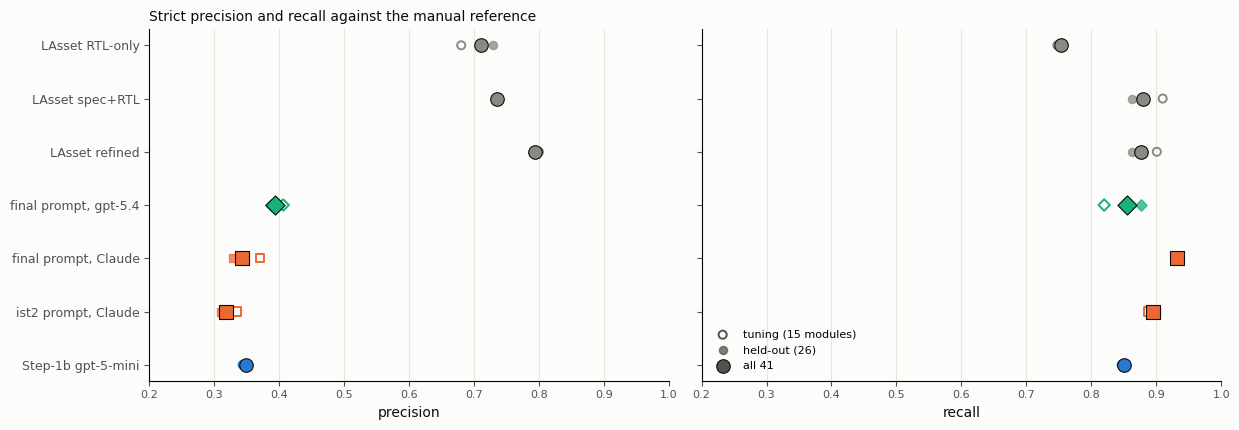

In [14]:
FAM = {"LAsset": ("#8a8984", "o"), "gpt-5.4": ("#1baf7a", "D"), "Claude": ("#eb6834", "s"), "gpt-5-mini": ("#2a78d6", "o")}
fam = lambda c: "LAsset" if c.startswith("LAsset") else "gpt-5.4" if "gpt-5.4" in c else "Claude" if "Claude" in c else "gpt-5-mini"
SPLIT_STYLE = {"tuning": dict(s=34, facecolors="none", linewidths=1.4), "heldout": dict(s=34, alpha=0.75),
               "all41": dict(s=95, edgecolors="#0b0b0b", linewidths=0.8)}
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4), sharey=True, facecolor="#fcfcfb")
ys = list(range(len(table)))[::-1]
for ax, m, name in ((axes[0], "P", "precision"), (axes[1], "R", "recall")):
    ax.set_facecolor("#fcfcfb")
    for y, (_, row) in zip(ys, table.iterrows()):
        c, mk = FAM[fam(row["config"])]
        for split, style in SPLIT_STYLE.items():
            v = row[f"{m}_{split}"]
            if pd.notna(v):
                kw = dict(style)
                kw.setdefault("facecolors", c)
                ax.scatter(v, y, marker=mk, edgecolors=kw.pop("edgecolors", c), zorder=3, **kw)
    ax.set_xlim(0.2, 1.0); ax.set_xlabel(name, color="#0b0b0b"); ax.grid(axis="x", color="#e6e5e0")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.tick_params(colors="#52514e", labelsize=8)
axes[0].set_yticks(ys); axes[0].set_yticklabels(table["config"], fontsize=9)
for split, label in (("tuning", "tuning (15 modules)"), ("heldout", "held-out (26)"), ("all41", "all 41")):
    axes[1].scatter([], [], color="#52514e", label=label, **{k: v for k, v in SPLIT_STYLE[split].items() if k != "facecolors"},
                    facecolors="none" if split == "tuning" else "#52514e")
axes[1].legend(fontsize=8, frameon=False, loc="lower left")
axes[0].set_title("Strict precision and recall against the manual reference", loc="left", fontsize=10, color="#0b0b0b")
plt.tight_layout(); plt.show()

**How sure are the differences?** A module bootstrap resamples the 41 modules with replacement and recomputes pooled
precision and recall; the brackets are 95% intervals for "configuration minus LAsset list". They cover variation between
modules, not between runs.

In [15]:
rows = []
for cfg in ("final prompt, gpt-5.4", "final prompt, Claude", "Step-1b gpt-5-mini"):
    for against in ("LAsset RTL-only", "LAsset spec+RTL"):
        b = R41.bootstrap_vs(ns, mods, cfg, against)
        for scope in ("all41", "heldout", "tuning"):
            s = b[scope]
            if "dP" not in s:
                rows.append({"configuration": cfg, "against": against, "modules": scope, "precision difference": s["status"], "recall difference": ""})
                continue
            rows.append({"configuration": cfg, "against": against, "modules": scope,
                         "precision difference": f"{s['dP']:+.3f} [{s['dP_lo']:+.3f}, {s['dP_hi']:+.3f}]",
                         "recall difference": f"{s['dR']:+.3f} [{s['dR_lo']:+.3f}, {s['dR_hi']:+.3f}]"})
boot = pd.DataFrame(rows).set_index(["configuration", "against", "modules"])
boot

precision difference        recall difference
configuration         against         modules                                                  
final prompt, gpt-5.4 LAsset RTL-only all41    -0.316 [-0.392, -0.232]  +0.102 [+0.037, +0.167]
                                      heldout  -0.342 [-0.439, -0.227]  +0.120 [+0.057, +0.182]
                                      tuning   -0.274 [-0.392, -0.157]  +0.072 [-0.065, +0.225]
                      LAsset spec+RTL all41    -0.341 [-0.395, -0.274]  -0.024 [-0.080, +0.030]
                                      heldout  -0.346 [-0.416, -0.250]  +0.014 [-0.044, +0.076]
                                      tuning   -0.331 [-0.413, -0.243]  -0.090 [-0.191, +0.014]
final prompt, Claude  LAsset RTL-only all41    -0.367 [-0.449, -0.270]  +0.179 [+0.128, +0.229]
                                      heldout  -0.401 [-0.499, -0.253]  +0.175 [+0.115, +0.235]
                                      tuning   -0.309 [-0.414, -0.203]  +0.186 [+0.103, +0.289]
                      LAsset spec+RTL all41    -0.392 [-0.449, -0.309]  +0.052 [+0.011, +0.092]
                                      heldout  -0.405 [-0.474, -0.282]  +0.069 [+0.015, +0.120]
                                      tuning   -0.366 [-0.437, -0.275]  +0.024 [-0.035, +0.087]
Step-1b gpt-5-mini    LAsset RTL-only all41    -0.362 [-0.423, -0.293]  +0.097 [+0.039, +0.154]
                                      heldout  -0.378 [-0.457, -0.286]  +0.095 [+0.013, +0.163]
                                      tuning   -0.336 [-0.437, -0.232]  +0.099 [+0.012, +0.204]
                      LAsset spec+RTL all41    -0.387 [-0.431, -0.333]  -0.030 [-0.084, +0.022]
                                      heldout  -0.383 [-0.442, -0.307]  -0.011 [-0.089, +0.059]
                                      tuning   -0.393 [-0.452, -0.320]  -0.063 [-0.127, +0.018]

In [16]:
def reading(cfg, against, scope="all41"):
    s = R41.bootstrap_vs(ns, mods, cfg, against)[scope]
    if "dP" not in s:
        return f"{cfg} vs {against} ({scope}): {s['status']}"
    word = lambda lo, hi: "higher" if lo > 0 else "lower" if hi < 0 else "not distinguishable (interval includes zero)"
    return (f"{cfg} vs {against} ({scope}): precision {word(s['dP_lo'], s['dP_hi'])}, "
            f"recall {word(s['dR_lo'], s['dR_hi'])}")
for cfg in ("final prompt, gpt-5.4", "final prompt, Claude"):
    for against in ("LAsset RTL-only", "LAsset spec+RTL"):
        print(reading(cfg, against))
        print(reading(cfg, against, "heldout"))

final prompt, gpt-5.4 vs LAsset RTL-only (all41): precision lower, recall higher
final prompt, gpt-5.4 vs LAsset RTL-only (heldout): precision lower, recall higher
final prompt, gpt-5.4 vs LAsset spec+RTL (all41): precision lower, recall not distinguishable (interval includes zero)


final prompt, gpt-5.4 vs LAsset spec+RTL (heldout): precision lower, recall not distinguishable (interval includes zero)
final prompt, Claude vs LAsset RTL-only (all41): precision lower, recall higher
final prompt, Claude vs LAsset RTL-only (heldout): precision lower, recall higher
final prompt, Claude vs LAsset spec+RTL (all41): precision lower, recall higher


final prompt, Claude vs LAsset spec+RTL (heldout): precision lower, recall higher


Per module, the final prompt (gpt-5.4, mean over its three runs) beside LAsset's two initial lists:

In [17]:
pm = R41.per_module(ns, mods, "final prompt, gpt-5.4")
pm.assign(module=pm["module"].str.replace("neorv32_", "")).set_index(["split", "module"]).round(2)

entries  runs     TP     FP  LAsset_RTL_TP  LAsset_RTL_FP  LAsset_specRTL_TP  LAsset_specRTL_FP
split   module                                                                                                           
tuning  bus                    11     3   9.67   9.00            8.0            2.0                9.0                2.0
        cache                   6     3   2.00  24.67            4.0            2.0                5.0                3.0
        cpu                    14     3   8.00   1.00           12.0            2.0               13.0                2.0
        cpu_cp_cfu             11     3   7.00   7.67            9.0            4.0               10.0                4.0
        cpu_cp_muldiv          12     3  11.33   5.67           11.0            3.0               12.0                4.0
        cpu_pmp                 6     3   6.00   7.00            4.0            3.0                5.0                1.0
        debug_dtm               5     3   5.00  12.33            4.0            3.0                4.0                3.0
        hwspinlock              2     3   2.00   0.00            2.0            0.0                2.0                0.0
        imem                    3     3   2.67   4.00            3.0            1.0                3.0                1.0
        spi                     8     3   8.00  16.00            5.0            3.0                8.0                3.0
        sys                     2     3   1.33   9.00            1.0            0.0                1.0                1.0
        trng                    7     3   6.00   5.00            4.0            3.0                6.0                3.0
        twi                     6     3   6.00  13.67            2.0            9.0                6.0                5.0
        uart                   10     3   9.00  12.67            8.0            1.0               10.0                2.0
        wdt                     8     3   7.00   5.33            6.0            3.0                7.0                2.0
heldout cpu_alu                11     3   8.67  11.00           10.0            2.0               10.0                2.0
        cpu_control            11     3   6.33  56.00            7.0            3.0                8.0                6.0
        cpu_counters           11     3  10.00   4.00            9.0            5.0                9.0                3.0
        cpu_cp_bitmanip         7     3   7.00  17.33            6.0            5.0                6.0                4.0
        cpu_cp_cond             6     3   6.00   1.00            5.0            1.0                5.0                1.0
        cpu_cp_crypto           6     3   6.00  14.67            4.0            3.0                5.0                3.0
        cpu_cp_fpu             12     3   8.67  18.00            8.0            2.0                9.0                4.0
        cpu_cp_shifter         11     3  10.00   2.33            8.0            0.0                9.0                1.0
        cpu_decompressor        3     3   3.00   1.00            2.0            3.0                3.0                1.0
        cpu_frontend            3     3   1.00  10.00            2.0            2.0                3.0                3.0
        cpu_icc                 5     3   5.00   4.00            4.0            0.0                4.0                0.0
        cpu_lsu                10     3   9.67   2.67            7.0            2.0                9.0                2.0
        cpu_regfile             8     3   7.67   0.67            7.0            1.0                6.0                2.0
        debug_auth              5     3   3.67   1.00            4.0            0.0                5.0                0.0
        debug_dm                6     3   6.00  17.67            4.0            0.0                4.0                1.0
        dmem                    3     3   3.00   4.00            3.0            1.0                3.0                1.0


## 7. How the prompt converged

Every scored prompt version on the tuning set. The logs: `logs/ABLATION_LOG.md` (v1, recall study), `logs/ABLATION_LOG_V2.md`
(v2, precision study), `notebooks/assetgen_meta.ipynb` (meta prompts and hand arms), `step1/lasset_step1/RELATION_EXPERIMENTS_LOG.md`
(traced arms), `assetgen_meta/prompt_opt/OPTIMIZATION_LOG.md` (the optimization loop). `final/build_convergence.py`
rebuilt every row from the run folders with the same scorer; its self-test checks known figures from the logs before
it writes anything. It needs the run folders that are not published, so it is kept as a record. The `log_source` column
of the CSV names the log entry behind each row. The CSV also keeps the versions that have no run, so that each decision stays
visible; the table below shows only versions with a run. The blind-agent side study (`blind_agent/`) is left out of the plot and kept in the table.

July went into replicating LAsset (its specification retrieval, the closed set by code, a first generation run and
a root-cause pass over its false positives), the RTL parser and the evaluation framework. Scored runs start in August.
`docs/TIMELINE.md` has the whole sequence with the decision at each step.

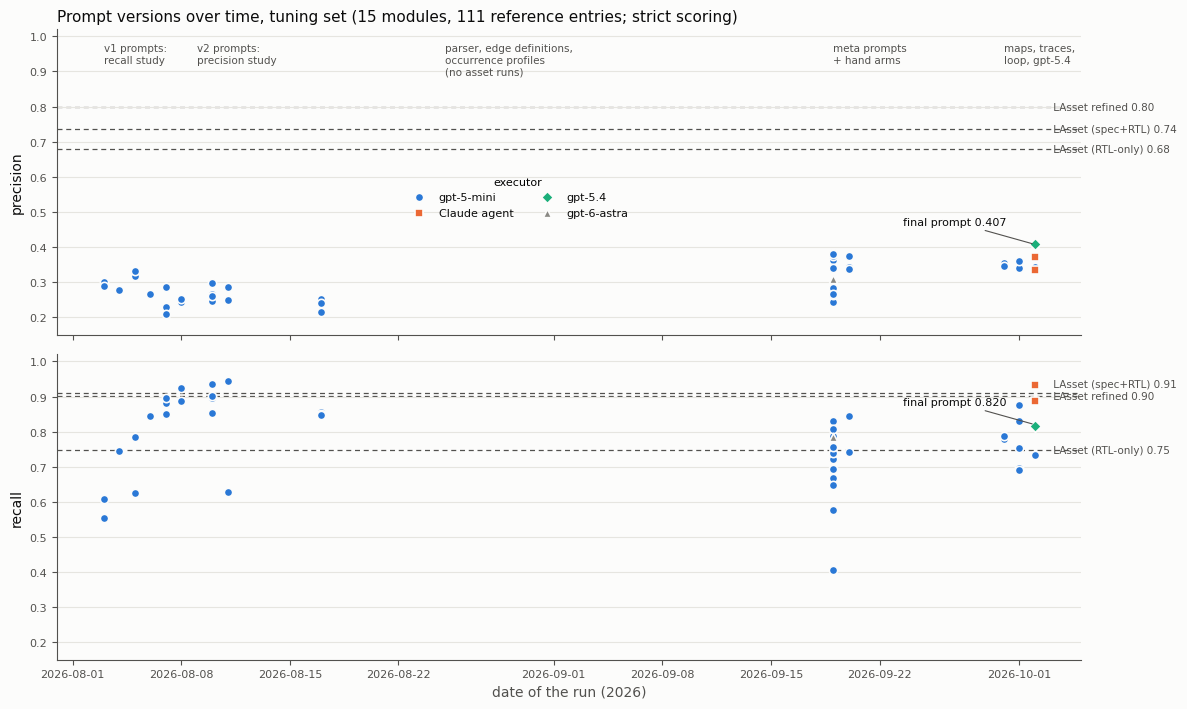

In [18]:
fig, (ax_p, ax_r) = plt.subplots(2, 1, figsize=(12, 7.2), sharex=True, facecolor="#fcfcfb")
plotted = FP.convergence_plot(ax_p, ax_r)
plt.tight_layout(); plt.show()

In [19]:
conv = pd.read_csv("final/convergence.csv")
conv["executor"] = conv["executor"].str.split(" [(]").str[0]
conv["date"] = conv["date"].fillna("").astype(str).str.slice(0, 10)
keep = ["version", "stage", "executor", "date", "runs_complete", "P_mean", "R_mean"]
conv[conv["runs_complete"] > 0][keep].reset_index(drop=True)

,version,stage,executor,date,runs_complete,P_mean,R_mean
0,LAsset initial (RTL-only),0 external reference (LAsset),LAsset pipeline,,1,0.680,0.748
1,LAsset initial (spec+RTL),0 external reference (LAsset),LAsset pipeline,,1,0.737,0.910
2,LAsset refined,0 external reference (LAsset),LAsset pipeline,,1,0.800,0.901
3,v0,"1 recall study, v1 prompts",gpt-5-mini,2026-08-03,3,0.300,0.553
4,v01,"1 recall study, v1 prompts",gpt-5-mini,2026-08-03,3,0.288,0.607
5,v01c2,"1 recall study, v1 prompts",gpt-5-mini,2026-08-04,5,0.277,0.744
6,v01c3,"1 recall study, v1 prompts",gpt-5-mini,2026-08-05,5,0.318,0.784
7,v01r,"1 recall study, v1 prompts",gpt-5-mini,2026-08-05,2,0.331,0.626
8,v01c4,"1 recall study, v1 prompts",gpt-5-mini,2026-08-06,5,0.267,0.845
9,v01c5,"1 recall study, v1 prompts",gpt-5-mini,2026-08-07,5,0.285,0.849


The held-out checks of earlier versions (26 modules):

In [20]:
held = pd.read_csv("final/heldout.csv")
held["executor"] = held["executor"].str.split(" [(]").str[0]
held[["version", "executor", "runs_complete", "P_mean", "R_mean"]]

,version,executor,runs_complete,P_mean,R_mean
0,LAsset initial (RTL-only),LAsset pipeline,1,0.730,0.757
1,LAsset initial (spec+RTL),LAsset pipeline,1,0.734,0.862
2,LAsset refined,LAsset pipeline,1,0.791,0.862
3,m7e194es0ism,gpt-5-mini,3,0.352,0.852
4,blind_D1,claude-opus-5-5,2,0.362,0.619
5,opt_v1,claude-opus-5-5,1,0.329,0.931
6,opt_v0,claude-opus-5-5,1,0.310,0.899


## 8. The audit trail

Each listed asset gives one row of the ledger: the element, whether it is a hit (TP) or a false positive (FP) against
the reference, the role the model gave it, the **occurrence ID** it cited, that occurrence's line and text, the
relationship record it cited, and whether the citation is true. `trace_check` decides the last column against the
map, without an LLM. `verified`: the occurrence exists, sits on that line, and carries that record. `map gap
claimed`: the model cited the occurrence but said the map lacks the record it needed; only the occurrence is checked.

The ledger below covers the final prompt's gpt-5.4 runs on all 41 modules (three runs per module); the Claude runs are
analysed the same way in section 10. In the CSV ledger under `final/fp_trace41/`, the column `family` is the fault
reporter's grouping, not the structural roles of section 10.

In [21]:
import fp_trace41 as FT
claude = FT.analyse_config(ns, mods, "final prompt, Claude")
g54 = FT.analyse_config(ns, mods, "final prompt, gpt-5.4")
for res in (claude, g54):
    if len(res["ledger"]):
        FT.write(res)
prim, other = g54, claude          # the main configuration and the check
led = prim["ledger"]
print(f"{len(led)} listed assets, {led['run'].nunique()} runs, {led['module'].nunique()} modules")
fpl = led[led["label"] == "FP"]
print(f"false-positive listings {len(fpl)}; distinct false-positive elements (module, entity, element) "
      f"{fpl[['module', 'entity', 'element']].drop_duplicates().shape[0]}")
prim["citations"].set_index(["split", "label"])

1953 listed assets, 6 runs, 41 modules
false-positive listings 1183; distinct false-positive elements (module, entity, element) 500


listed  verified  edge, role unfit  map gap claimed  occurrence only  verified share  edge, role unfit share  map gap claimed share  occurrence only share
split          label                                                                                                                                                            
tuning         FP        399       385                 0               14                0           0.965                   0.000                  0.035                  0.000
               TP        273       271                 0                2                0           0.993                   0.000                  0.007                  0.000
heldout        FP        784       764                11                8                1           0.974                   0.014                  0.010                  0.001
               TP        497       495                 2                0                0           0.996                   0.004                  0.000                  0.000
all 41 modules FP       1183      1149                11               22                1           0.971                   0.009                  0.019                  0.001
               TP        770       766                 2                2                0           0.995                   0.003                  0.003                  0.000

One module, one run, the whole list: the watchdog timer (tuning) and the GPIO controller (held-out).

In [22]:
cols = ["element", "label", "role", "occurrence", "line", "rtl", "cited_edge", "citation"]
pd.concat({m.replace("neorv32_", ""): led[(led["module"] == m) & (led["run"].isin(["assets_tuning18_m7e194es0opt1_g54_r0", "assets_heldout26_m7e194es0opt1_g54_r0"]))][cols]
           for m in ("neorv32_wdt", "neorv32_gpio")}).reset_index(level=1, drop=True)

,element,label,role,occurrence,line,rtl,cited_edge,citation
wdt,ctrl.enable,TP,stores,3,94,ctrl.enable <= bus_req_i.data(ctrl_enable_c);,CLOCKED_BY clk_i,verified
wdt,clkgen_en_o,TP,exit port,2,140,clkgen_en_o <= ctrl.enable;,COPIES ctrl.enable,verified
wdt,ctrl.lock,TP,stores,4,95,ctrl.lock <= bus_req_i.data(ctrl_lock_c) and ctrl.enable;,CLOCKED_BY clk_i,verified
wdt,ctrl.strict,FP,stores,3,96,ctrl.strict <= bus_req_i.data(ctrl_strict_c);,CLOCKED_BY clk_i,verified
wdt,ctrl.timeout,TP,stores,3,97,ctrl.timeout <= bus_req_i.data(ctrl_timeout_msb_c downto ctrl_timeout_lsb_c);,CLOCKED_BY clk_i,verified
wdt,cnt_started,FP,stores,4,130,cnt_started <= ctrl.enable and (cnt_started or prsc_tick);,CLOCKED_BY clk_i,verified
wdt,cnt,TP,stores,4,134,cnt <= std_ulogic_vector(unsigned(cnt) + 1);,CLOCKED_BY clk_i,verified
wdt,reset_wdt,TP,stores,4,103,reset_wdt <= '1';,CLOCKED_BY clk_i,verified
wdt,reset_force,FP,stores,4,99,reset_force <= '1';,CLOCKED_BY clk_i,verified
wdt,hw_rst_timeout,FP,stores,3,155,hw_rst_timeout <= ctrl.enable and cnt_timeout and prsc_tick;,CLOCKED_BY clk_i,verified


## 9. The evidence layer on LAsset's own list

Can the map judge someone else's list? I ran the same occurrence evidence over LAsset's published RTL-only list for
the 26 held-out modules. The hypotheses, decision rules and file hashes were written before the layer was run on
the held-out set: `assetgen_meta/lasset_layer/PREREG.md`. Both readings use 97.5% intervals (Bonferroni over two).

- **H1 (audit):** a model trained on the tuning set ranks LAsset's held-out hits above its false positives
  (AUC interval above 0.5).
- **H2 (filter):** a threshold fixed on the tuning set raises LAsset's held-out precision, beyond what random removal
  of the same number of items does. If it removes items in fewer than four modules, H2 is "not testable".

In [23]:
L = FP.lasset_layer_result()
print(f"H1: AUC {L['H1']['auc']:.3f}, 97.5% interval [{L['H1']['lo']:.3f}, {L['H1']['hi']:.3f}], {L['H1']['resamples']} resamples")
print(f"H2: list P {L['H2']['P']:.3f} / R {L['H2']['R']:.3f}; items the rule removed: {L['H2']['dropped']}")
for k, v in L["verdicts"].items():
    print(f"{k}: {v}")

H1: AUC 0.639, 97.5% interval [0.495, 0.768], 10000 resamples
H2: list P 0.730 / R 0.757; items the rule removed: 0
H1_audit: does not hold
H2_filter: not testable
claim: audit trail only: the map traces LAsset's items but does not tell its hits from its false positives


So on LAsset's list the map is an **audit trail**: it ties each item to lines and records. It is **not a filter**.

## 10. Why the false positives do not go down, traced through occurrence IDs and the relationship map

Two months of prompt changes moved precision up and down, but never close to LAsset's lists (section 7), and on all 41
modules the final prompt stays far below LAsset in precision (section 6). The ledger lets us ask why, at the level of the code evidence. Each
listed asset has a **relationship profile**: its kind and storage, and the classes of records it carries, such as
"controlled <- input port" or "data -> output port". Six questions:

1. Are the false positives misreadings of the code?
2. What evidence do they cite?
3. Do hits and false positives carry the same kinds of relationships?
4. Can the profile tell them apart, also on modules it has not seen?
5. If rules built from the profile are found on the tuning modules, what do they do on the held-out modules?
6. Which structural roles do the false positives come from?

The main analysis uses the gpt-5.4 runs of the final prompt (three runs on each of the 41 modules). The same readings
for the Claude runs are in the right-hand column of the first table, and printed beside the main ones where it matters.

In [24]:
def headline(res):
    h = FT.summary(res)
    flat = {}
    for k, v in h.items():
        if k in ("config", "scores", "coverage"):
            continue
        if isinstance(v, dict):
            for kk, vv in v.items():
                flat[f"{k}: {kk}"] = vv
        else:
            flat[k] = v
    return pd.Series(flat, dtype=object)
pd.concat({"final prompt, gpt-5.4": headline(g54), "final prompt, Claude": headline(claude)}, axis=1, sort=False).fillna("")

,"final prompt, gpt-5.4","final prompt, Claude"
scope,all 41 modules,all 41 modules
pooled readings over,all 41 modules,all 41 modules
listed assets (pooled over runs),1953,1373
hits,770,487
FPs,1183,886
FP citations verified,1149/1183 (0.971),830/886 (0.937)
hit citations verified,766/770 (0.995),484/487 (0.994)
record type cited by the most FPs,"CLOCKED_BY: 0.596 of FPs, 0.316 of hits","CLOCKED_BY: 0.490 of FPs, 0.314 of hits"
assets citing no record (edge null) that are FPs,22/24,55/58
relationship classes on both hits and FPs,13/13,13/13


**1-2. Grounded, and what they cite.** The citation table in section 8 shows that most false positives cite a real
occurrence with a true record, a slightly smaller share than the hits; nearly every listing that cites no record at all
is a false positive. The table below shows which record type each listed asset cites. A `CLOCKED_BY` citation says only
that the element is stored (a register or a stored output).

In [25]:
prim["cited_types"].set_index("cited type")

,hits,share of hits,FPs,share of FPs,FP share among assets citing it
cited type,,,,,
CLOCKED_BY,243,0.316,705,0.596,0.744
GATED_BY,91,0.118,168,0.142,0.649
DERIVES_FROM,112,0.145,118,0.100,0.513
COPIES,85,0.110,41,0.035,0.325
SELECTED_BY,13,0.017,32,0.027,0.711
CONNECTS,19,0.025,27,0.023,0.587
none,2,0.003,22,0.019,0.917
SOURCES,84,0.109,18,0.015,0.176
GATES,41,0.053,18,0.015,0.305


**3. The same relationships.** For each relationship class (and each element attribute), the share of hits and of false
positives that carry it. Points on the dashed line are carried equally often by both.

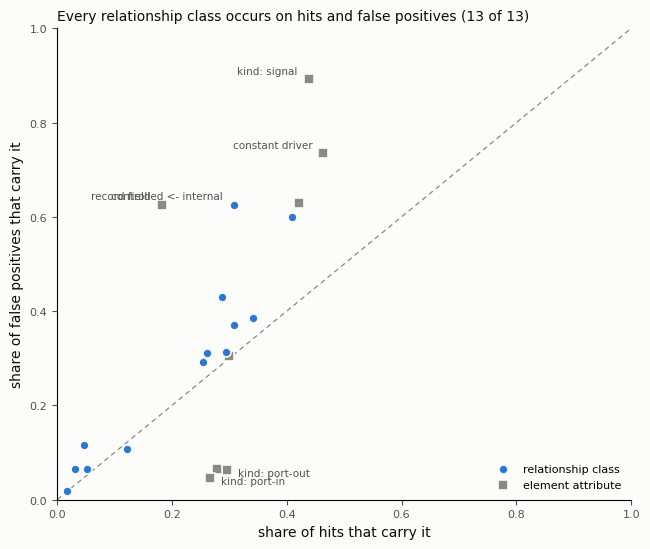

,token kind,hits_with,hits_share,fp_with,fp_share
token,,,,,
kind: signal,element attribute,337,0.438,1055,0.892
constant driver,element attribute,357,0.464,870,0.735
storage: stored,element attribute,325,0.422,745,0.630
reset,relationship class,315,0.409,710,0.600
controlled <- internal,relationship class,237,0.308,740,0.626
record field,element attribute,141,0.183,741,0.626
control -> internal,relationship class,222,0.288,509,0.430
controlled <- input port,relationship class,263,0.342,455,0.385
data <- internal,relationship class,238,0.309,439,0.371


In [26]:
ct = prim["overlap"]["class table"].set_index("token")
fig, ax = plt.subplots(figsize=(6.6, 5.6), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
ax.plot([0, 1], [0, 1], color="#8a8984", lw=0.9, ls=(0, (4, 3)), zorder=1)
for kind, (c, mk) in {"relationship class": ("#2a78d6", "o"), "element attribute": ("#8a8984", "s")}.items():
    x = ct[ct["token kind"] == kind]
    ax.scatter(x["hits_share"], x["fp_share"], s=42, color=c, marker=mk, edgecolors="#fcfcfb", linewidths=1.2,
               zorder=4 if kind == "relationship class" else 3, label=kind)
gap = (ct["fp_share"] - ct["hits_share"]).abs().sort_values(ascending=False)
for i, name in enumerate(gap.index[:6]):
    above = ct.loc[name, "fp_share"] > ct.loc[name, "hits_share"]
    ax.annotate(name, (ct.loc[name, "hits_share"], ct.loc[name, "fp_share"]), xytext=(-8, 4) if above else (8, -4),
                textcoords="offset points", fontsize=7.5, color="#52514e", ha="right" if above else "left")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel("share of hits that carry it", color="#0b0b0b"); ax.set_ylabel("share of false positives that carry it", color="#0b0b0b")
ov = prim["overlap"]
ax.set_title(f"Every relationship class occurs on hits and false positives "
             f"({ov['relationship classes on both hits and FPs']} of {ov['relationship classes']})", fontsize=10, loc="left", color="#0b0b0b")
ax.legend(fontsize=8, frameon=False, loc="lower right")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.tick_params(colors="#52514e", labelsize=8)
plt.tight_layout(); plt.show()
ct[["token kind", "hits_with", "hits_share", "fp_with", "fp_share"]]

In [27]:
ex = prim["overlap"]["exact profile"]
print(f"False positives whose exact profile (all classes and attributes together) also belongs to a hit: "
      f"{ex['FPs whose exact profile a hit has']}/{prim['overlap']['FPs']} ({ex['share']:.3f}); "
      f"to a hit in another module: {ex['... of a hit in another module']} ({ex['share (other module)']:.3f}); "
      f"in the other split: {ex['... of a hit in the other split']} ({ex['share (other split)']:.3f})")

False positives whose exact profile (all classes and attributes together) also belongs to a hit: 282/1183 (0.238); to a hit in another module: 268 (0.227); in the other split: 202 (0.171)


**4. Can the profile tell them apart?** A logistic model predicts hit or false positive from the profile. AUC is a
ranking measure (0.5 = no better than chance, 1.0 = perfect); it is neither precision nor recall. "Leave one module
out" trains on 40 modules and tests on the 41st, for each module in turn. "Train tuning, test held-out" never sees
the held-out modules while it learns.

In [28]:
sep = prim["separability"]
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
lr = lambda: LogisticRegression(max_iter=2000, random_state=FT.SEED)
def per_split_auc(ledger):
    dd = ledger[ledger["in_map"]].reset_index(drop=True)
    y, g, spl = (dd["label"] == "TP").to_numpy(), dd["module"].to_numpy(), dd["split"].to_numpy()
    X = FT._features(dd, "profile")
    def unseen(train_pool, test):          # each tested module is scored by a model that never saw it
        p = np.full(len(y), np.nan)
        for m in sorted(set(g[test])):
            te = g == m
            p[te] = lr().fit(X[train_pool & ~te], y[train_pool & ~te]).predict_proba(X[te])[:, 1]
        return round(float(roc_auc_score(y[test], p[test])), 3)
    T, H, A = spl == "tuning", spl == "heldout", np.ones(len(y), bool)
    ins = lambda m: round(float(roc_auc_score(y[m], lr().fit(X[m], y[m]).predict_proba(X[m])[:, 1])), 3)
    return pd.DataFrame({"in-sample": [ins(T), ins(H)],
                         "unseen module, trained on the other modules of its split": [unseen(T, T), unseen(H, H)],
                         "unseen module, trained on all 40 other modules": [unseen(A, T), unseen(A, H)]},
                        index=["15 tuning modules tested", "26 held-out modules tested"])
display(pd.DataFrame(sep["features"]).T)
pd.concat({"final prompt, gpt-5.4": per_split_auc(led), "final prompt, Claude": per_split_auc(other["ledger"])})

,in-sample,leave one module out,"leave one module out, one row per element","train tuning, test held-out"
profile,0.845,0.805,0.818,0.792
profile + cited type + role,0.851,0.804,0.818,0.763
exact record types,0.853,0.798,0.817,0.764


in-sample  unseen module, trained on the other modules of its split  unseen module, trained on all 40 other modules
final prompt, gpt-5.4 15 tuning modules tested        0.776                                                     0.644                                           0.678
                      26 held-out modules tested      0.911                                                     0.869                                           0.875
final prompt, Claude  15 tuning modules tested        0.762                                                     0.629                                           0.662
                      26 held-out modules tested      0.889                                                     0.836                                           0.838

**5. Rules found on the tuning modules, applied unchanged to the held-out modules.** The fault reporter finds code rules
that drop clusters of mostly false positives on the tuning runs. They are applied, without change, to the held-out run.
A random-removal control drops the same number of listed assets at random. These rules are fitted to the reference's
labels, so they measure how much the structure separates the reference's choices; they are not a filter to deploy.

In [29]:
tr = prim["transfer"]
ho, rnd, la, ins = tr["held-out"], tr["random removal"], tr["LAsset RTL-only, held-out"], tr["in-sample (tuning)"]
print(f"{tr['rule count']} rules found on the tuning runs ({', '.join(tr['tuning runs'])})")
print(f"in-sample (tuning):  removes {ins['FPs removed']}/{ins['FP total']} FPs and {ins['hits lost']}/{ins['hit total']} hits; "
      f"P {ins['P before']} -> {ins['P after']}, R {ins['R before']} -> {ins['R after']}")
print(f"held-out (unchanged): removes {ho['FPs removed']}/{ho['FP total']} FPs and {ho['hits lost']}/{ho['hit total']} hits; "
      f"P {ho['P before']} -> {ho['P after']} ({ho['exact']['P before']} -> {ho['exact']['P after']}), "
      f"R {ho['R before']} -> {ho['R after']} ({ho['exact']['R before']} -> {ho['exact']['R after']})")
print(f"random removal of {rnd['assets removed per draw']} assets, {rnd['draws']} draws: mean P {rnd['mean P after']}, "
      f"mean R {rnd['mean R after']}; draws reaching the rules' precision: {rnd['exact']['draws with P >= the rules P']}")
print(f"LAsset RTL-only on the same held-out modules: P {la['P']}, R {la['R']}")
hc = other["transfer"]["held-out"]
print(f"check, Claude runs ({other['transfer']['rule count']} rules): P {hc['P before']} -> {hc['P after']}, R {hc['R before']} -> {hc['R after']}")

30 rules found on the tuning runs (runs/assets_tuning18_m7e194es0opt1_g54_r0, runs/assets_tuning18_m7e194es0opt1_g54_r1, runs/assets_tuning18_m7e194es0opt1_g54_r2)
in-sample (tuning):  removes 330/399 FPs and 97/273 hits; P 0.406 -> 0.718, R 0.82 -> 0.529
held-out (unchanged): removes 501/784 FPs and 158/497 hits; P 0.388 -> 0.545 (497/1281 -> 339/622), R 0.877 -> 0.598 (497/567 -> 339/567)
random removal of 659 assets, 2000 draws: mean P 0.388, mean R 0.426; draws reaching the rules' precision: 0/2000
LAsset RTL-only on the same held-out modules: P 0.73, R 0.757
check, Claude runs (31 rules): P 0.329 -> 0.478, R 0.931 -> 0.64


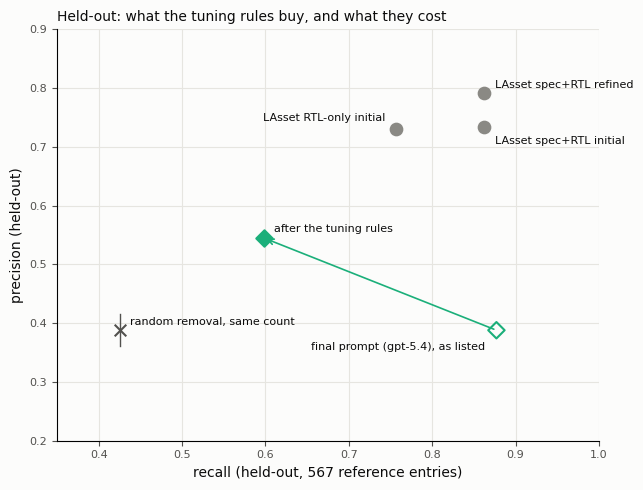

In [30]:
fig, ax = plt.subplots(figsize=(6.6, 5.0), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
lh = FT.lasset_scores(ns, mods, "heldout")
pts = [("final prompt (gpt-5.4), as listed", ho["R before"], ho["P before"], "#1baf7a", "D", "none"),
       ("after the tuning rules", ho["R after"], ho["P after"], "#1baf7a", "D", "#1baf7a"),
       ("random removal, same count", rnd["mean R after"], rnd["mean P after"], "#52514e", "x", "#52514e")]
pts += [(k, v["R"], v["P"], "#8a8984", "o", "#8a8984") for k, v in lh.items()]
OFFSET = {"LAsset RTL-only initial": (-8, 6, "right"), "LAsset spec+RTL initial": (8, -12, "left"),
          "LAsset spec+RTL refined": (8, 4, "left"), "final prompt (gpt-5.4), as listed": (-8, -14, "right")}
for name, r, p, c, mk, fc in pts:
    ax.scatter(r, p, s=70, marker=mk, color=c, facecolors=fc, linewidths=1.5, zorder=3)
    dx, dy, ha = OFFSET.get(name, (7, 4, "left"))
    ax.annotate(name, (r, p), xytext=(dx, dy), textcoords="offset points", fontsize=8, color="#0b0b0b", ha=ha)
lo, hi = rnd["P 2.5-97.5%"]
ax.plot([rnd["mean R after"]] * 2, [lo, hi], color="#52514e", lw=1, zorder=2)
ax.annotate("", xy=(ho["R after"], ho["P after"]), xytext=(ho["R before"], ho["P before"]),
            arrowprops={"arrowstyle": "->", "color": "#1baf7a", "lw": 1.2})
ax.set_xlim(0.35, 1.0); ax.set_ylim(0.2, 0.9)
ax.set_xlabel(f"recall (held-out, {ho['reference entries']} reference entries)", color="#0b0b0b"); ax.set_ylabel("precision (held-out)", color="#0b0b0b")
ax.set_title("Held-out: what the tuning rules buy, and what they cost", fontsize=10, loc="left", color="#0b0b0b")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.grid(color="#e6e5e0"); ax.tick_params(colors="#52514e", labelsize=8)
plt.tight_layout(); plt.show()

**6. Which structural roles the false positives come from.** Every map element gets one structural role from the map
alone, by the first test that fits: input port; output port; **input-written register** (a stored signal written from an
input port in one step; this includes pin samples, operand latches and memories, not only configuration);
**exported state register** (any other stored signal whose value reaches an output port through combinational signals);
**internal state register** (any other stored signal); sub-unit interface; **combinational decision** (a signal whose
conditions or selections decide other assignments); combinational data; not assigned here. A record takes the first
role among its fields. For each role: its share among all elements of the 41 modules, among the reference's
assets, among LAsset's RTL-only list and among the final prompt's lists, with the precision inside the role
(hits / listed entries of that role). The gpt-5.4 column pools its six runs (three per module); the Claude column
uses one run per module (tuning r0 and the held-out run).

In [31]:
import module_insights as MI
lists, _ = MI.default_lists(ns, mods)
lists["final prompt, gpt-5.4, all 41"] = lists["final prompt, gpt-5.4, tuning"] + lists["final prompt, gpt-5.4, heldout"]
lists["reference, heldout"] = [x for x in lists["reference"] if x[0] == "heldout"]
enrich = MI.role_enrichment(ns, mods, lists)
share_cols = ["all elements share", "reference share", "LAsset RTL-only share", "final prompt, gpt-5.4, all 41 share", "final prompt, Claude, r0 share"]
p_cols = ["LAsset RTL-only P", "final prompt, gpt-5.4, all 41 P", "final prompt, Claude, r0 P"]
enrich["gpt-5.4 / reference (ratio of shares)"] = (enrich["final prompt, gpt-5.4, all 41 share"] / enrich["reference share"]).round(1)
print({k: v for k, v in enrich.attrs["denominators"].items()})
display(enrich[share_cols + ["gpt-5.4 / reference (ratio of shares)"] + p_cols])
AR = MI.all_roles(mods)
base = {sp: AR[AR["split"] == sp]["role"].value_counts(normalize=True) for sp in ("tuning", "heldout")}
by_split = pd.DataFrame({
    ("tuning", "all elements"): base["tuning"], ("tuning", "reference"): enrich["reference, tuning share"],
    ("tuning", "gpt-5.4"): enrich["final prompt, gpt-5.4, tuning share"], ("tuning", "gpt-5.4 P"): enrich["final prompt, gpt-5.4, tuning P"],
    ("held-out", "all elements"): base["heldout"], ("held-out", "reference"): enrich["reference, heldout share"],
    ("held-out", "gpt-5.4"): enrich["final prompt, gpt-5.4, heldout share"], ("held-out", "gpt-5.4 P"): enrich["final prompt, gpt-5.4, heldout P"],
}).reindex(list(MI.ROLES)).astype(float).round(3)
print("by module set (shares; P = precision inside the role):")
by_split

{'all elements': 3354, 'reference': {'entries': 300, 'matched': 297, 'not matched': 3, 'hits': None}, 'reference, tuning': {'entries': 111, 'matched': 110, 'not matched': 1, 'hits': None}, 'LAsset RTL-only': {'entries': 318, 'matched': 300, 'not matched': 18, 'hits': 226}, 'final prompt, Claude, r0': {'entries': 810, 'matched': 810, 'not matched': 0, 'hits': 280}, 'final prompt, gpt-5.4, tuning': {'entries': 672, 'matched': 672, 'not matched': 0, 'hits': 273}, 'final prompt, gpt-5.4, heldout': {'entries': 1281, 'matched': 1281, 'not matched': 0, 'hits': 497}, 'final prompt, gpt-5.4, all 41': {'entries': 1953, 'matched': 1953, 'not matched': 0, 'hits': 770}, 'reference, heldout': {'entries': 189, 'matched': 187, 'not matched': 2, 'hits': None}}


,all elements share,reference share,LAsset RTL-only share,"final prompt, gpt-5.4, all 41 share","final prompt, Claude, r0 share",gpt-5.4 / reference (ratio of shares),LAsset RTL-only P,"final prompt, gpt-5.4, all 41 P","final prompt, Claude, r0 P"
input port,0.380,0.300,0.247,0.133,0.163,0.4,0.865,0.788,0.644
output port,0.257,0.263,0.227,0.154,0.135,0.6,0.941,0.757,0.697
input-written register,0.068,0.199,0.213,0.242,0.193,1.2,0.719,0.371,0.372
exported state register,0.036,0.044,0.063,0.109,0.120,2.5,0.421,0.184,0.134
internal state register,0.069,0.037,0.060,0.159,0.165,4.3,0.389,0.103,0.082
sub-unit interface,0.067,0.074,0.087,0.058,0.107,0.8,0.615,0.283,0.195
combinational decision,0.032,0.047,0.057,0.073,0.072,1.6,0.706,0.287,0.207
combinational data,0.058,0.037,0.047,0.072,0.046,1.9,0.500,0.128,0.216
not assigned here,0.032,0.000,0.000,0.000,0.000,NaN,NaN,NaN,NaN
(no map element; not in shares),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


by module set (shares; P = precision inside the role):


tuning                                 held-out                            
                        all elements reference gpt-5.4 gpt-5.4 P all elements reference gpt-5.4 gpt-5.4 P
input port                     0.333     0.236   0.121     0.691        0.425     0.337   0.140     0.832
output port                    0.403     0.191   0.149     0.630        0.117     0.305   0.157     0.821
input-written register         0.049     0.200   0.249     0.383        0.086     0.198   0.238     0.364
exported state register        0.026     0.055   0.143     0.188        0.046     0.037   0.091     0.181
internal state register        0.039     0.082   0.149     0.260        0.098     0.011   0.165     0.028
sub-unit interface             0.059     0.127   0.048     0.500        0.075     0.043   0.063     0.198
combinational decision         0.018     0.064   0.071     0.417        0.045     0.037   0.074     0.221
combinational data             0.035     0.045   0.071     0.208        0.081     0.032   0.073     0.086
not assigned here              0.038     0.000   0.000       NaN        0.026     0.000   0.000       NaN

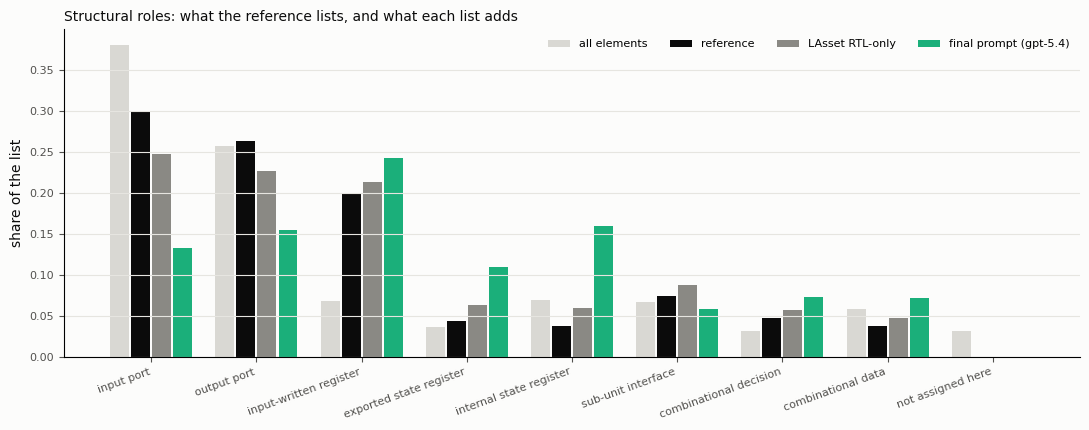

In [32]:
E = enrich.drop(index="(no map element; not in shares)")
series = [("all elements", "all elements share", "#d9d8d3"), ("reference", "reference share", "#0b0b0b"),
          ("LAsset RTL-only", "LAsset RTL-only share", "#8a8984"), ("final prompt (gpt-5.4)", "final prompt, gpt-5.4, all 41 share", "#1baf7a")]
fig, ax = plt.subplots(figsize=(11, 4.4), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
w = 0.2
for i, (label, col, c) in enumerate(series):
    ax.bar([x + (i - 1.5) * w for x in range(len(E))], E[col].fillna(0), width=w - 0.02, color=c, label=label)
ax.set_xticks(range(len(E))); ax.set_xticklabels(E.index, rotation=20, ha="right", fontsize=8)
ax.set_ylabel("share of the list", color="#0b0b0b")
ax.set_title("Structural roles: what the reference lists, and what each list adds", fontsize=10, loc="left", color="#0b0b0b")
ax.legend(fontsize=8, frameon=False, ncol=4)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.tick_params(colors="#52514e", labelsize=8); ax.grid(axis="y", color="#e6e5e0")
plt.tight_layout(); plt.show()

**What would a role rule do?** The simplest rule a prompt could state is to leave out a whole role. Applied to the
final prompt's lists above (gpt-5.4: its runs pooled, so recall is the mean over runs; Claude: one run per module). The
role was chosen after seeing the reference's role shares above, so this is an in-sample check, not a tested rule:

In [33]:
def role_rule(label, ref):
    n_role, p_role = E[f"{label} n"], E[f"{label} P"].fillna(0)
    hits_role = (n_role * p_role).round().astype(int)
    N, Hh = int(n_role.sum()), int(hits_role.sum())
    out = [{"list": label, "rule": "none (as listed)", "listings removed": 0, "hits removed": 0, "P": round(Hh / N, 3), "R": round(Hh / ref, 3)}]
    for drop in (["internal state register"], ["internal state register", "exported state register"]):
        dn, dh = int(n_role[drop].sum()), int(hits_role[drop].sum())
        out.append({"list": label, "rule": "leave out " + " and ".join(drop), "listings removed": dn, "hits removed": dh,
                    "P": round((Hh - dh) / (N - dn), 3), "R": round((Hh - dh) / ref, 3)})
    return out
g = table.set_index("config").loc["final prompt, gpt-5.4"]
ref_g54 = int(g["runs_tuning"]) * mods["entries"]["tuning"] + int(g["runs_heldout"]) * mods["entries"]["heldout"]
rows = (role_rule("final prompt, gpt-5.4, all 41", ref_g54)
        + role_rule("final prompt, gpt-5.4, tuning", int(g["runs_tuning"]) * mods["entries"]["tuning"])
        + role_rule("final prompt, gpt-5.4, heldout", int(g["runs_heldout"]) * mods["entries"]["heldout"])
        + role_rule("final prompt, Claude, r0", mods["entries"]["tuning"] + mods["entries"]["heldout"]))
la41 = table.set_index("config").loc["LAsset RTL-only"]
rows.append({"list": "LAsset RTL-only", "rule": "for scale (all 41)", "P": round(la41["P_all41"], 3), "R": round(la41["R_all41"], 3)})
pd.DataFrame(rows).set_index(["list", "rule"]).fillna("")

listings removed hits removed      P      R
list                           rule                                                                                                     
final prompt, gpt-5.4, all 41  none (as listed)                                                           0.0          0.0  0.394  0.856
                               leave out internal state register                                        311.0         32.0  0.449  0.820
                               leave out internal state register and exported state register            523.0         71.0  0.489  0.777
final prompt, gpt-5.4, tuning  none (as listed)                                                           0.0          0.0  0.406  0.820
                               leave out internal state register                                        100.0         26.0  0.432  0.742
                               leave out internal state register and exported state register            196.0         44.0  0.481  0.688
final prompt, gpt-5.4, heldout none (as listed)                                                           0.0          0.0  0.388  0.877
                               leave out internal state register                                        211.0          6.0  0.459  0.866
                               leave out internal state register and exported state register            327.0         27.0  0.493  0.829
final prompt, Claude, r0       none (as listed)                                                           0.0          0.0  0.346  0.933
                               leave out internal state register                                        134.0         11.0  0.398  0.897
                               leave out internal state register and exported state register            231.0         24.0  0.442  0.853
LAsset RTL-only                for scale (all 41)                                                                           0.711  0.753

**Minimal pairs.** A hit and a false positive with exactly the same profile and the same cited record type, each traced
to its occurrence, line and record. The profile and the cited record type are the same; at that level nothing
separates them, yet the reference lists one and not the other.

In [34]:
mp = prim["minimal_pairs"]
mp.assign(module=mp["module"].str.replace("neorv32_", ""))[
    ["pair", "side", "profile", "split", "module", "element", "occurrence", "line", "rtl", "cited edge", "citation"]].set_index(["pair", "side"])

profile    split           module       element  occurrence  line  \
pair side                                                                                                                                                                  
1    TP    constant driver; control -> internal; controlled <- input port; data -> output port; data <- inp...  heldout            gptmr   timer.thres           3    84   
     FP    constant driver; control -> internal; controlled <- input port; data -> output port; data <- inp...  heldout           neoled  ctrl.t_total           3   135   
2    TP                                                        data <- internal; kind: port-out; storage: comb  heldout          cpu_alu         cmp_o           2   102   
     FP                                                        data <- internal; kind: port-out; storage: comb  heldout      cpu_control   csr_rdata_o           2  1595   
3    TP                                            data -> internal; kind: port-in; storage: not assigned here   tuning              cpu         mei_i           2   276   
     FP                                            data -> internal; kind: port-in; storage: not assigned here   tuning            cache       wdata_i           2   414   
4    TP    constant driver; control -> internal; controlled <- internal; kind: signal; record field; reset;...   tuning              bus    keeper.cnt           4   422   
     FP    constant driver; control -> internal; controlled <- internal; kind: signal; record field; reset;...  heldout  cpu_cp_bitmanip     clmul.cnt           3   359   
5    TP    constant driver; controlled <- input port; data -> internal; data -> output port; data <- input ...   tuning             uart     ctrl.baud           3   183   
     FP    constant driver; controlled <- input port; data -> internal; data -> output port; data <- input ...  heldout           neoled     ctrl.mode           3   131   
6    TP    constant driver; control -> internal; controlled <- input port; data <- input port; kind: signal...  heldout          onewire    ctrl.clear           4   143   
     FP    constant driver; control -> internal; controlled <- input port; data <- input port; kind: signal...  heldout            slink   ctrl.rx_clr           4   149   

                                                                               rtl           cited edge  citation  
pair side                                                                                                          
1    TP                                             timer.thres <= bus_req_i.data;     CLOCKED_BY clk_i  verified  
     FP     ctrl.t_total  <= bus_req_i.data(ctrl_t_tot_4_c downto ctrl_t_tot_0_c);     CLOCKED_BY clk_i  verified  
2    TP                                                   cmp_o            <= cmp;           COPIES cmp  verified  
     FP                                                  csr_rdata_o <= csr.rdata;     COPIES csr.rdata  verified  
3    TP                                      irq_machine <= mti_i & mei_i & msi_i;  SOURCES irq_machine  verified  
     FP         data_mem_b0(to_integer(unsigned(acc_adr))) <= wdata_i(7 downto 0);  SOURCES data_mem_b0  verified  
4    TP                 keeper.cnt <= std_ulogic_vector(unsigned(keeper.cnt) + 1);     CLOCKED_BY clk_i  verified  
     FP       clmul.cnt <= std_ulogic_vector(to_unsigned(XLEN, clmul.cnt'length));     CLOCKED_BY clk_i  verified  
5    TP    ctrl.baud          <= bus_req_i.data(ctrl_baud9_c downto ctrl_baud0_c);     CLOCKED_BY clk_i  verified  
     FP                              ctrl.mode     <= bus_req_i.data(ctrl_mode_c);     CLOCKED_BY clk_i  verified  
6    TP                             ctrl.clear    <= bus_req_i.data(ctrl_clear_c);     CLOCKED_BY clk_i  verified  
     FP                              ctrl.rx_clr <= bus_req_i.data(ctrl_rx_clr_c);     CLOCKED_BY clk_i  verified

**Concepts the reference leaves empty.** The model groups its assets under concepts (for example "watchdog
configuration"). A false positive in a concept where the reference lists nothing at all is not a near miss: the model
and the reference disagree about whether that part of the module holds an asset.

In [35]:
pd.DataFrame(prim["concepts"]).T

,concepts listed,concepts with no reference element,FP total,FPs whose first concept lists no reference element,share (first concept),FPs none of whose concepts lists one,share (none of its concepts),FPs listed under more than one concept,fp_diagnosis D5
all 41 modules,824,260,1183,539,0.456,525,0.444,67,"{'concepts': 798, 'concepts with no reference element': 291, 'FPs in them': 686, 'FP total': 118..."
tuning,302,98,399,223,0.559,218,0.546,23,"{'concepts': 302, 'concepts with no reference element': 107, 'FPs in them': 237, 'FP total': 399..."
heldout,522,162,784,316,0.403,307,0.392,44,"{'concepts': 496, 'concepts with no reference element': 184, 'FPs in them': 449, 'FP total': 784..."


In [36]:
# the falsification test named in the earlier version of this analysis, decided from the numbers above
d_p = ho["P after"] - ho["P before"]
d_r = ho["R after"] - ho["R before"]
print(f"held-out precision {d_p:+.3f}, recall {d_r:+.3f} after the tuning rules; "
      f"rules' precision {'reaches' if ho['P after'] >= la['P'] else 'stays below'} LAsset RTL-only's, "
      f"recall {'stays at or above' if ho['R after'] >= la['R'] else 'falls below'} LAsset RTL-only's")
print("leave-one-module-out AUC over 41 modules:", sep["features"]["profile"]["leave one module out"],
      "| train tuning, test held-out:", sep["features"]["profile"]["train tuning, test held-out"])

held-out precision +0.157, recall -0.279 after the tuning rules; rules' precision stays below LAsset RTL-only's, recall falls below LAsset RTL-only's
leave-one-module-out AUC over 41 modules: 0.805 | train tuning, test held-out: 0.792


*Reading (my interpretation of the measurements above, not a measurement).*

- **The gap is not an artefact of tuning.** The final prompt's precision on the held-out modules is close to its
  precision on the tuning modules, and far below LAsset's on both.
- **Most false positives are not misreadings.** Nearly all cite a real occurrence with a true record. Many cite only a
  clock edge, which says no more than "this element is stored".
- **The structure carries some signal, unevenly.** The profile ranks hits above false positives on modules it has not
  seen, much better on the held-out modules than on the tuning modules. On the tuning modules the drop from in-sample
  to unseen remains even when the model learns from all 40 other modules. So the earlier reading, that "those
  differences weaken on a module the rule has not seen", still holds for the tuning modules; the held-out modules are
  easier to separate.
- **Using the signal costs recall.** Rules found on the tuning modules beat random removal on the held-out modules, but
  they buy precision with a large share of the hits, and neither precision nor recall reaches LAsset's RTL-only list.
  The test named in the earlier published version of this notebook ("If those rules raise held-out precision
  substantially without a large recall loss, the separation *is* structural and general, and this explanation is
  wrong") is not met: the precision comes only with a large recall loss. A simple role rule, leaving out internal state
  registers, removes mostly false positives on the held-out modules at a small recall cost, but costs more recall on the
  tuning modules; it is an in-sample check, and precision stays far below LAsset's either way.
- **Where the false positives come from.** Over all 41 modules the final prompt lists internal and exported state
  registers at several times the reference's rate (the ratio column), with low precision inside those roles. The module
  sets differ: on the held-out modules the reference almost never lists internal state, while on the tuning modules it
  lists it above its share of all elements (the table by module set). Nearly half
  of the false positives sit in concepts where the reference lists nothing; the rest sit in parts of a module the
  reference also covers. A sizeable minority have exactly the profile of a hit, often in another module; for these the
  profile cannot separate the two (the minimal pairs).
- **The check agrees.** The Claude runs of the same prompt show the same pattern in the readings printed beside the
  main ones (citations, the AUC by module set, rule transfer, roles); more than half of their false positives sit in
  concepts the reference leaves empty.

So, on this evidence, rules built from the code structure do not bring precision near LAsset's without losing recall;
whether a differently worded prompt could was not tested. On the held-out modules, part of the gap is a role
preference the structure shows (the reference there almost never lists internal state). The rest is a choice among
elements that these profiles separate only partly.
That is the explanation this audit trail supports; LAsset's accuracy numbers alone cannot show it.

**What would change this reading.** If other executors, more runs or a differently worded prompt produced lists, or
rules built from the structure, that bring precision near LAsset's without a large recall loss, the separation would be
structural after all.

## 11. What the occurrence profiles and the relationship map reveal about the modules

The asset list answers one question: which elements are assets. The two structures answer others, from code alone and
with a line for every fact. Definitions (all from the code-built map; `final/module_insights.py` gives the exact rules):

- **register**: a signal stored across clock cycles (it, or the record it belongs to, has a clock record);
- **input-written register**: a register whose new value comes from an input port in one step. This includes pin
  samples, operand latches and memories, not only configuration. "From write data" when one of those ports is a
  write-data port (bus, debug-module interface or CSR write data); that still includes memory arrays, because the map
  does not tell configuration from data;
- **exported register**: a register whose value reaches an output port through combinational signals only (the role
  "exported state register" of section 10 is an exported register that is not input-written);
- **control hub**: an element whose conditions decide the assignment of at least five other elements;
- **write guard**: an element whose condition gates the writes of at least two input-written registers (internal
  guards are signals, not bus ports; `ctrl.lock` in the watchdog is one);
- **reset coverage**: registers with a reset record. A reset value built from a generic gets no reset record, so the
  registers counted without one are an upper bound.

One row per module:

In [37]:
P41 = MI.portraits(mods)
cols = ["module", "split", "elements", "occurrences", "records", "registers", "input_written_registers",
        "input_written_from_write_data", "exported_registers", "registers_with_reset", "clocks", "control_hubs", "top_hub",
        "write_guards", "write_guards_internal", "subunit_instances", "reference_entries"]
T41 = P41[cols].assign(module=P41["module"].str.replace("neorv32_", "")).set_index(["split", "module"])
print("totals over the 41 modules:", T41.drop(columns=["top_hub"]).sum(numeric_only=True).to_dict())
T41

totals over the 41 modules: {'elements': 3354, 'occurrences': 17757, 'records': 8768, 'registers': 522, 'input_written_registers': 192, 'input_written_from_write_data': 116, 'exported_registers': 225, 'registers_with_reset': 496, 'clocks': 38, 'control_hubs': 113, 'write_guards': 68, 'write_guards_internal': 12, 'subunit_instances': 46, 'reference_entries': 300}


elements  occurrences  records  registers  input_written_registers  input_written_from_write_data  exported_registers  registers_with_reset  clocks  control_hubs                top_hub  \
split   module                                                                                                                                                                                                       
tuning  bus                    870         1640      575         17                        5                              0                   5                    17       1             3               sel (14)   
        cache                   86          427      259         16                        4                              4                   7                    10       1             2        ctrl.state (22)   
        cpu                    115          211       14          0                        0                              0                   0                     0       0             0                          
        cpu_cp_cfu              29          153      104          6                        3                              1                   3                     6       1             2           funct3_i (9)   
        cpu_cp_muldiv           70          399      175         10                        6                              0                   3                    10       1             2   ctrl_i.ir_funct3 (9)   
        cpu_pmp                 62          251      127          3                        2                              2                   2                     3       1             0                          
        debug_dtm               42          403      228         18                        4                              0                   8                    18       1             6      tap_reg.ireg (12)   
        hwspinlock              21           63       31          1                        1                              0                   1                     1       1             0                          
        imem                    27          156       90          7                        5                              4                   1                     1       1             1               addr (5)   
        spi                     66          473      286         19                       11                             10                  13                    19       1             5    bus_req_i.addr (13)   
        sys                     17           87       73          5                        1                              0                   4                     5       1             0                          
        trng                    56          235      127         10                        4                              2                   5                     9       1             0                          
        twi                     65          492      260         16                        4                              4                   8                    15       1             5     bus_req_i.addr (7)   
        uart                    76          593      346         26                       14                             12                  12                    26       1             5    bus_req_i.addr (15)   
        wdt                     39          177      139         12                        4                              4                   7                    12       1             3       bus_req_i.rw (7)   
heldout cpu_alu                 74          320      110          2                        0                              0                   2                     2       1             0                          
        cpu_control            233         2229     1144         88                        4                              0                  29                    86       1 

**Internal write guards.** Signals (not input ports) whose condition protects writes to input-written
registers, with the line that does it. Two of them are checks a security review would look for first: the watchdog's
lock (`ctrl.lock`) and the debug module's write authorisation (`dmi_wren_auth`). The others are state, busy, valid, run,
enable or start signals that gate datapath or interface registers.

In [38]:
gl = []
for split in ("tuning", "heldout"):
    for m in mods[split]:
        for g in MI.guards(split, m):
            if g["guard_role"] != "input port":
                gl.append({"module": m.replace("neorv32_", ""), "guard": g["guard"], "guard role": g["guard_role"], "line": g["line"],
                           "condition": g["condition"], "protects": ", ".join(g["protects"])})
pd.DataFrame(gl).set_index(["module", "guard"])

guard role  line                                                                                            condition  \
module         guard                                                                                                                                               
bus            state          internal state register    58                                                            not (state = S_BUSY_A) | state = S_BUSY_A   
               state          internal state register    63                                                            not (state = S_BUSY_B) | state = S_BUSY_B   
cpu_cp_muldiv  ctrl.state     internal state register   213                                                                                 ctrl.state /= S_IDLE   
               ctrl.state     internal state register   284                                                       (ctrl.state = S_BUSY) or (ctrl.state = S_DONE)   
               ctrl.state     internal state register   284                                                       (ctrl.state = S_BUSY) or (ctrl.state = S_DONE)   
               div.start       combinational decision   261                                            div.start = '1' | div.start = '1' | not (div.start = '1')   
               mul.start       combinational decision   170                                                                                      mul.start = '1'   
               mul.start       combinational decision   210                                                              mul.start = '1' | not (mul.start = '1')   
wdt            ctrl.lock       input-written register    93                                                                                      ctrl.lock = '0'   
cpu_cp_crypto  cmd_valid       combinational decision   312                                                                                      cmd_valid = '1'   
cpu_cp_shifter shifter.run     combinational decision    96                                                                                    shifter.run = '1'   
               valid_cmd       combinational decision    93                                                              not (valid_cmd = '1') | valid_cmd = '1'   
debug_dm       dm_ctrl.busy    combinational decision   438  (dmi_req_i.addr = addr_command_c) and (dmi_wren_auth = '1') and (dm_ctrl.busy = '0') and (dm_ctr...   
               dm_ctrl.busy    combinational decision   443            (dmi_req_i.addr = addr_abstractauto_c) and (dmi_wren_auth = '1') and (dm_ctrl.busy = '0')   
               dm_ctrl.busy    combinational decision   464                (dmi_req_i.addr = addr_progbuf0_c) and (dmi_wren_auth = '1') and (dm_ctrl.busy = '0')   
               dm_ctrl.busy    combinational decision   469                (dmi_req_i.addr = addr_progbuf1_c) and (dmi_wren_auth = '1') and (dm_ctrl.busy = '0')   
               dmi_wren_auth   combinational decision   425                                                                                  dmi_wren_auth = '1'   
               dmi_wren_auth   combinational decision   438  (dmi_req_i.addr = addr_command_c) and (dmi_wren_auth = '1') and (dm_ctrl.busy = '0') and (dm_ctr...   
               dmi_wren_auth   combinational decision   443            (dmi_req_i.addr = addr_abstractauto_c) and (dmi_wren_auth = '1') and (dm_ctrl.busy = '0')   
               dmi_wren_auth   combinational decision   464                (dmi_req_i.addr = addr_progbuf0_c) and (dmi_wren_auth = '1') and (dm_ctrl.busy = '0')   
               dmi_wren_auth   combinational decision   469                (dmi_req_i.addr = addr_progbuf1_c) and (dmi_wren_auth = '1') and (dm_ctrl.busy = '0')   
twd            ctrl.enable     input-written register   315                                                          ctrl.enable = '1' | not (ctrl.enable = '1')   
               smp.clk_en      combinational decision   316                                                

**One module in depth: the watchdog timer.** Its software-writable registers, who guards their writes, whether they
reset, where their values go, and whether the reference lists them.

In [39]:
dd = MI.deep_dive("tuning", "neorv32_wdt")
pd.DataFrame(dd["input_written_registers"]).set_index("register")

,written_from,from_write_data,write_lines,reset,reaches_outputs,guarded_by,listed
register,,,,,,,
ctrl.enable,[bus_req_i.data],True,[94],True,"[bus_rsp_o.data, clkgen_en_o]","[bus_req_i.addr, bus_req_i.rw, bus_req_i.stb, ctrl.lock]",True
ctrl.lock,[bus_req_i.data],True,[95],True,[bus_rsp_o.data],"[bus_req_i.addr, bus_req_i.rw, bus_req_i.stb]",True
ctrl.strict,[bus_req_i.data],True,[96],True,[bus_rsp_o.data],"[bus_req_i.addr, bus_req_i.rw, bus_req_i.stb, ctrl.lock]",False
ctrl.timeout,[bus_req_i.data],True,[97],True,[bus_rsp_o.data],"[bus_req_i.addr, bus_req_i.rw, bus_req_i.stb, ctrl.lock]",True


In [40]:
outs = pd.DataFrame(dd["outputs"])
print("outputs fed by registers:")
print(outs[outs["registers"].map(len) > 0][["output", "registers", "listed", "registers_listed"]].to_string(index=False))
pd.DataFrame(dd["reference"]).set_index("reference entry")

outputs fed by registers:
        output                                                        registers  listed                                    registers_listed
bus_rsp_o.data [ctrl.enable, ctrl.lock, ctrl.strict, ctrl.timeout, reset_cause]   False [ctrl.enable, ctrl.lock, ctrl.timeout, reset_cause]
   clkgen_en_o                                                    [ctrl.enable]    True                                       [ctrl.enable]
        rstn_o                                  [hw_rst_access, hw_rst_timeout]   False                                                  []


,element,role,write guard,input-written register,reaches an output,control hub
reference entry,,,,,,
ctrl.enable,ctrl.enable,input-written register,False,True,True,False
ctrl.lock,ctrl.lock,input-written register,True,True,True,False
ctrl.timeout,ctrl.timeout,input-written register,False,True,True,False
cnt,cnt,internal state register,False,False,False,False
cnt_timeout,cnt_timeout,combinational data,False,False,False,False
reset_cause,reset_cause,exported state register,False,False,True,False
reset_wdt,reset_wdt,internal state register,False,False,False,False
clkgen_en_o,clkgen_en_o,output port,False,False,False,False


*Reading (what this adds, not a measurement).* For every module the two structures give a checkable account of its
structure: which registers are written from an input, and which of those from a write-data port; which signals guard
those writes, and on which line; which registers may have no reset (an upper bound); which internal values leave the
module, and through which outputs; and which elements decide the most others. LAsset's list carries no line references
of its own; section 9 shows that the map can attach them but not judge them. These tables can be checked line by line,
and they would let a reviewer ask concrete questions of a design without an LLM in the loop: for example, is every
register written from bus write data reset? Is a lock register itself write-protected once it is set?

## 12. Limits

- **Runs.** gpt-5.4 has three runs on every module; the Claude check has one run on the held-out modules. My tuning
  figures are in-sample: the prompts were chosen on those 15 modules.
- **One reference.** Every precision figure counts disagreement with one manual list. A false positive here is an
  element the reference does not list; it is not proof that the element is not an asset.
- **LAsset rows are re-scored lists, not reruns.** They are LAsset's published outputs, scored with my strict scorer.
- **The bootstrap intervals cover module-to-module variation only**, not run-to-run variation.
- **The relationship gold was written by an LLM** and adjudicated, on the tuning modules only. The held-out maps are
  checked by self-tests and line integrity, not against a gold sample.
- **The code rules in section 10 are fitted on the reference labels.** They are a diagnostic, not a filter to deploy.
- **The structural roles are readings of the code-built map.** They cover direct relationships within one entity;
  values that pass through sub-blocks or process variables are traced only as far as the connection. The thresholds
  for hubs and guards are fixed choices, not tuned.
- **Registers without a reset are an upper bound**: a reset value built from a generic gets no reset record.

**Where to go next in the repo:** `README.md` (map of the repo), `docs/TIMELINE.md` (July to October, with decisions),
`docs/LAYOUT.md` (folder layout), `logs/` and `assetgen_meta/prompt_opt/OPTIMIZATION_LOG.md` (the logs),
`notebooks/assetgen_meta.ipynb` (the ablation notebook), `notebooks/lasset_step1.ipynb` (occurrence profiles and relation
map on the 15 tuning modules), `notebooks/lasset_evidence_layer.ipynb` (section 9 in full), `final/results41.py`,
`final/fp_trace41.py` and `final/module_insights.py` (the code behind sections 6, 10 and 11, each with a self-test).